In [923]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [924]:
%precision 3

'%.3f'

In [925]:
x_set = np.array([1, 2, 3, 4, 5, 6])

In [926]:
def f(x):
    if x in x_set:
        return x / 21
    else:
        return 0

In [927]:
X = [x_set, f] # 확률변수

In [928]:
X

[array([1, 2, 3, 4, 5, 6]), <function __main__.f(x)>]

In [929]:
prob = np.array([f(x_k) for x_k in x_set])

In [930]:
prob

array([0.048, 0.095, 0.143, 0.19 , 0.238, 0.286])

<BarContainer object of 6 artists>

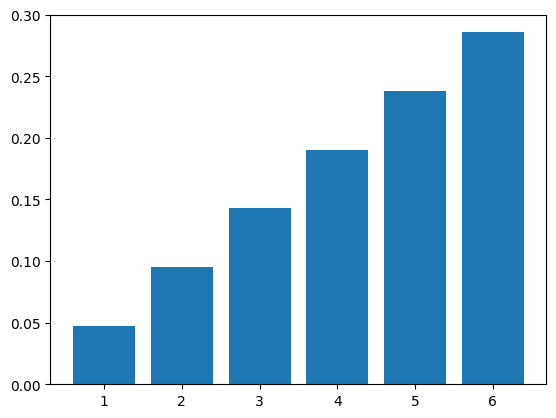

In [931]:
plt.bar(x_set, prob)

In [932]:
np.all(prob >= 0)

np.True_

확률질량함수 = 확률함수

In [933]:
def F(x):
    return np.sum([f(x_k) for x_k in x_set if x_k <= x])

In [934]:
F(3)

np.float64(0.2857142857142857)

## 확률변수의 변환
X에 2를 곱하고 3을 더한 2X + 3도 확률변수가 된다.

In [935]:
y_set = np.array([2 * x_k + 3 for x_k in x_set])

In [936]:
y_set

array([ 5,  7,  9, 11, 13, 15])

In [937]:
prob = np.array([f(x_k) for x_k in x_set])

In [938]:
prob

array([0.048, 0.095, 0.143, 0.19 , 0.238, 0.286])

In [939]:
dict(zip(y_set, prob))

{np.int64(5): np.float64(0.047619047619047616),
 np.int64(7): np.float64(0.09523809523809523),
 np.int64(9): np.float64(0.14285714285714285),
 np.int64(11): np.float64(0.19047619047619047),
 np.int64(13): np.float64(0.23809523809523808),
 np.int64(15): np.float64(0.2857142857142857)}

In [940]:
def g(y):
    x = (y-3) / 2
    return f(x)

In [941]:
Y = [y_set, g]

In [942]:
Y

[array([ 5,  7,  9, 11, 13, 15]), <function __main__.g(y)>]

In [943]:
np.array([g(y_k) for y_k in y_set])

array([0.048, 0.095, 0.143, 0.19 , 0.238, 0.286])

# 1차원 이산형 확률변수의 지표

## 기댓값
기댓값 (E(X)) = 확률변수의 평균

확률변수를 무제한 시행하여 얻어진 실현값의 평균

무제한 시행할 수 없으므로 확률변수가 취할 수 있는 값과 확률의 곱의 총합

E[X], E(X) => 두가지로 표현가능

평균내는 방법 --> 기댓값 산출 방식을 유도

기댓값으로 분산 구하는 공식 = 편차 제곱의 기댓값

$S_{xy} = {1 \over n} \sum\limits_{i = 1}^n (X_i - \bar{X})(Y_i - \bar{Y})$ = $E[(X_i - \bar{X})(Y_i - \bar{Y})]$

공분산으로 기댓값

$S_{2} = {1 \over n} \sum\limits_{i = 1}^n (X_i - \bar{X})^2 = E[(X_i - \bar{X})^2]$

In [944]:
prob

array([0.048, 0.095, 0.143, 0.19 , 0.238, 0.286])

In [945]:
x_set

array([1, 2, 3, 4, 5, 6])

In [946]:
s = 0
for i in x_set:
    s += i * prob[i-1]
print(s)

4.333333333333333


In [947]:
np.sum([x_k * f(x_k) for x_k in x_set])

np.float64(4.333333333333333)

100만(1e6)번 실행

In [948]:
sample = np.random.choice(x_set, int(1e6), p=prob)

In [949]:
sample

array([5, 6, 3, ..., 1, 5, 5])

In [950]:
np.mean(sample)

np.float64(4.330919)

In [951]:
def E_x(X):
    x_set, f = X
    return np.sum([x_k * f(x_k) for x_k in x_set])

In [952]:
E_x(X)

np.float64(4.333333333333333)

Y = 2X + 3의 기댓값을 생각해보자

g = x --> E(X)

g = 2x + 3 --> E(2X + 3)

g = 4x - 5 --> E(4X - 5)

In [953]:
X

[array([1, 2, 3, 4, 5, 6]), <function __main__.f(x)>]

In [954]:
def E(X, g=lambda x: x):
    x_set, f = X
    return sum([g(x_k)*f(x_k) for x_k in x_set])

In [955]:
E(X)

np.float64(4.333333333333333)

In [956]:
E(X, g=lambda x: 2*x + 3)

np.float64(11.666666666666664)

In [957]:
# 분산
mean = E(X)
np.sum([(x_k - mean)**2 * f(x_k) for x_k in x_set])

np.float64(2.2222222222222223)

In [958]:
def V(X, g=lambda x : x):
    x_set, f = X
    mean = E(X, g)
    return np.sum([(g(x_k) - mean)**2 * f(x_k) for x_k in x_set])

In [959]:
V(X)

np.float64(2.2222222222222223)

In [960]:
V(X, lambda x : 2*x + 3)

np.float64(8.88888888888889)

In [961]:
2**2 * V(X)

np.float64(8.88888888888889)

$V(2X + 3) = 2^2V(X)$

# 2차원 이산형 확률분포

### 결합 확률 분포: 두 개 이상의 확률변수에 대한 분포

확률변수 2개를 다룬다

$P(X = x_i, Y = y_j) = p_{ij} (i = 1, 2, ..., j = 1, 2, ...)$

예시 > 불공정한 주사위 A, B가 있을 때

    X = A와 B의 눈을 더한 것 = {2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
    Y = A의 눈 = {1, 2, 3, 4, 5, 6}
    A눈 = Y, B눈 = X - Y

x = 9 y = 4 --> A눈 = 4, B의 눈 = 5

P(Y = 4) = 4 / 21

P(B = 5) = 5 / 21

P(X = 9, Y = 4) = (4 / 21) * (5 / 21) = 20 / 441

In [962]:
x_set = np.arange(2, 13)
y_set = np.arange(1, 7)

In [963]:
x_set

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [964]:
y_set

array([1, 2, 3, 4, 5, 6])

In [965]:
def f_XY(x, y):
    if 1 <= y <= 6 and 1 <= x - y <= 6:
        return (y / 21) * ((x - y) / 21)
    else:
        return 0

In [966]:
XY = [x_set, y_set, f_XY]

In [967]:
prob = np.array([[f_XY(x_i, y_j) for y_j in y_set] for x_i in x_set])

In [968]:
prob

array([[0.002, 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.005, 0.005, 0.   , 0.   , 0.   , 0.   ],
       [0.007, 0.009, 0.007, 0.   , 0.   , 0.   ],
       [0.009, 0.014, 0.014, 0.009, 0.   , 0.   ],
       [0.011, 0.018, 0.02 , 0.018, 0.011, 0.   ],
       [0.014, 0.023, 0.027, 0.027, 0.023, 0.014],
       [0.   , 0.027, 0.034, 0.036, 0.034, 0.027],
       [0.   , 0.   , 0.041, 0.045, 0.045, 0.041],
       [0.   , 0.   , 0.   , 0.054, 0.057, 0.054],
       [0.   , 0.   , 0.   , 0.   , 0.068, 0.068],
       [0.   , 0.   , 0.   , 0.   , 0.   , 0.082]])

In [969]:
np.all(prob >= 0)

np.True_

In [970]:
np.sum(prob)

np.float64(0.9999999999999999)

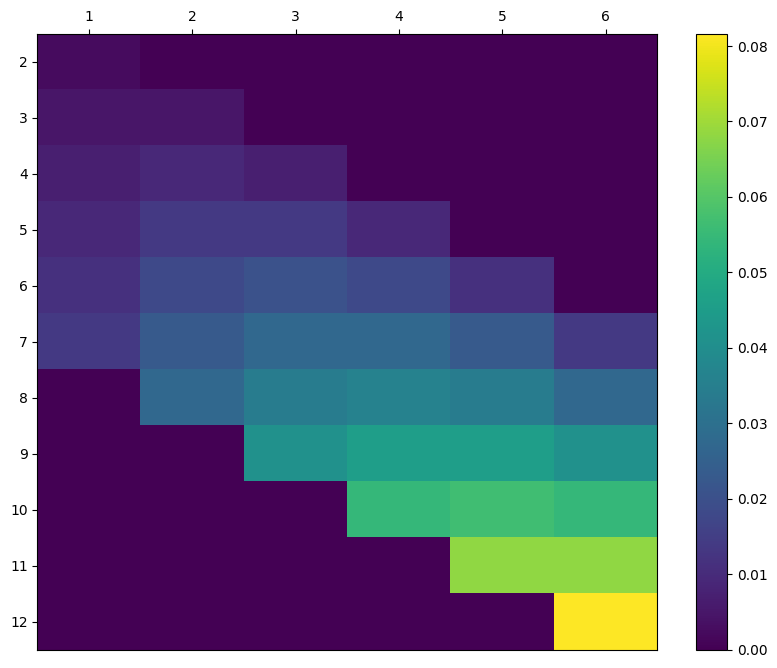

In [971]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
c = ax.pcolor(prob)
ax.set_xticks(np.arange(prob.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(prob.shape[0]) + 0.5, minor=False)
ax.set_xticklabels(np.arange(1, 7), minor=False)
ax.set_yticklabels(np.arange(2, 13), minor=False)
ax.invert_yaxis()
ax.xaxis.tick_top()
fig.colorbar(c, ax=ax)
plt.show()

# 주변확률분포 (marginal probability distribution)

$f_X(x) = \sum\limits_{k}f_{XY}(x, y_k)$

y값을 모두 대입시켜 함수를 확정한 후에, 이 함수들을 모두 더해 놓은 함수

In [972]:
def f_X(x):
    return np.sum([f_XY(x, y_k) for y_k in y_set])

위 함수는 f_XY 함수 중, y 값을 미리 모두 채워 놓은 상태

In [973]:
def f_Y(y):
    return np.sum([f_XY(x_k, y) for x_k in x_set])

In [974]:
X = [x_set, f_X]
Y = [y_set, f_Y]

In [975]:
X

[array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 <function __main__.f_X(x)>]

In [976]:
Y

[array([1, 2, 3, 4, 5, 6]), <function __main__.f_Y(y)>]

In [977]:
prob_x = np.array([f_X(x_k) for x_k in x_set])
prob_y = np.array([f_Y(y_k) for y_k in y_set])

In [978]:
prob_x, prob_y

(array([0.002, 0.009, 0.023, 0.045, 0.079, 0.127, 0.159, 0.172, 0.166,
        0.136, 0.082]),
 array([0.048, 0.095, 0.143, 0.19 , 0.238, 0.286]))

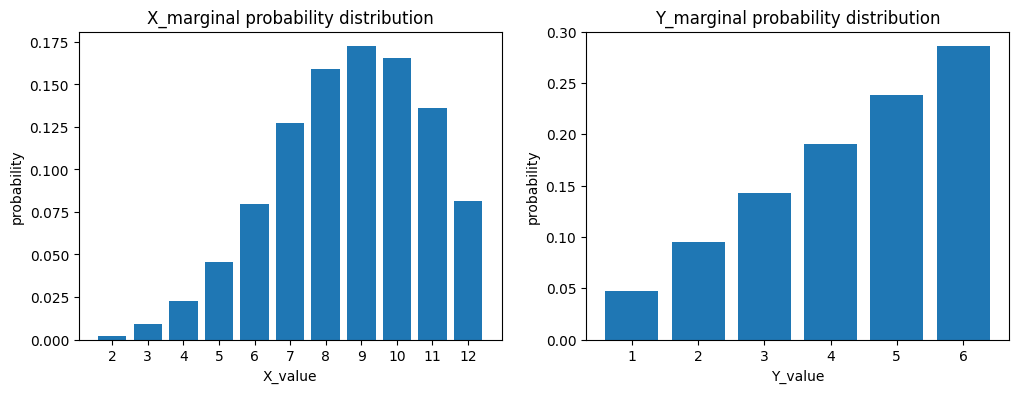

In [979]:
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.bar(x_set, prob_x)
ax1.set_title('X_marginal probability distribution')
ax1.set_xlabel('X_value')
ax1.set_ylabel('probability')
ax1.set_xticks(x_set)
ax2.bar(y_set, prob_y)
ax2.set_title('Y_marginal probability distribution')
ax2.set_xlabel('Y_value')
ax2.set_ylabel('probability')
plt.show()

## X의 기대값 계산

In [980]:
np.sum([(x_i) * f_XY(x_i, y_j) for x_i in x_set for y_j in y_set])

np.float64(8.666666666666664)

In [981]:
XY

[array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 array([1, 2, 3, 4, 5, 6]),
 <function __main__.f_XY(x, y)>]

In [982]:
def E_XY(XY, g):
    x_set, y_set, f_XY = XY
    return np.sum([g(x_i, y_j) * f_XY(x_i, y_j) for x_i in x_set for y_j in y_set])

In [983]:
mean_X = E_XY(XY, lambda x, y: x)
mean_X

np.float64(8.666666666666664)

In [984]:
mean_Y = E_XY(XY, lambda x, y: y)
mean_Y

np.float64(4.333333333333333)

In [985]:
a, b = 2, 3

In [986]:
E_XY(XY, lambda x, y : a*x + b*y)

np.float64(30.33333333333333)

In [987]:
a*mean_X + b*mean_Y

np.float64(30.33333333333333)

# 분산 3

x의 분산은 X에 관한 편차 제곱의 기댓값

함수에는 x,y값 모두 넣어주고, 함수와 곱해지는 값은 x에 대한 것만 수행

In [988]:
np.sum([(x_i - mean_X)**2 * f_XY(x_i, y_j) for x_i in x_set for y_j in y_set])

np.float64(4.444444444444444)

In [989]:
# 일반화
def V(XY, g):
    x_set, y_set, f_XY = XY
    mean = E_XY(XY, g)
    return np.sum([(g(x_i, y_j) - mean)**2 * f_XY(x_i, y_j) for x_i in x_set for y_j in y_set])

In [990]:
var_X = V(XY, g=lambda x, y: x)
var_Y = V(XY, g=lambda x, y: y)
var_X

np.float64(4.444444444444444)

### 공분산
두 확률변수 X, Y 사이의 상관성

In [991]:
def Cov(XY):
    x_set, y_set, f_XY = XY
    mean_X = E_XY(XY, lambda x, y: x)
    mean_Y = E_XY(XY, lambda x, y: y)
    return np.sum([(x_i - mean_X) * (y_j - mean_Y) * f_XY(x_i, y_j) for x_i in x_set for y_j in y_set])

In [992]:
cov_xy = Cov(XY)

In [993]:
a, b

(2, 3)

V(2X + 3Y) = ?

In [994]:
# V(2X + 3Y)
V(XY, lambda x, y : a*x + b*y)

np.float64(64.44444444444443)

In [995]:
a**2*var_X + b**2*var_Y + 2*a*b*cov_xy

np.float64(64.44444444444443)

# 연속형 확률 변수

In [996]:
from scipy import integrate
import warnings

In [997]:
warnings.filterwarnings('ignore',
                        category=integrate.IntegrationWarning)

상대 도수 = (계급에 속한 데이터 개수) / 전체 개수

X = [x_set, f]를 연속형 확률변수에 대해 정의해보자

확률변수가 취할 수 있는 값 = 구간$[x_0, x_1]$

$P(x_0 <= X <= x_1) = \int_{x_0}^{x_1}f(x)\,dx$

In [998]:
x_range = np.array([0, 1])

In [999]:
def f(x):
    if x_range[0] <= x <= x_range[1]:
        return 2*x
    else:
        return 0

## 연속형 확률변수 X

In [1000]:
X = [x_range, f]

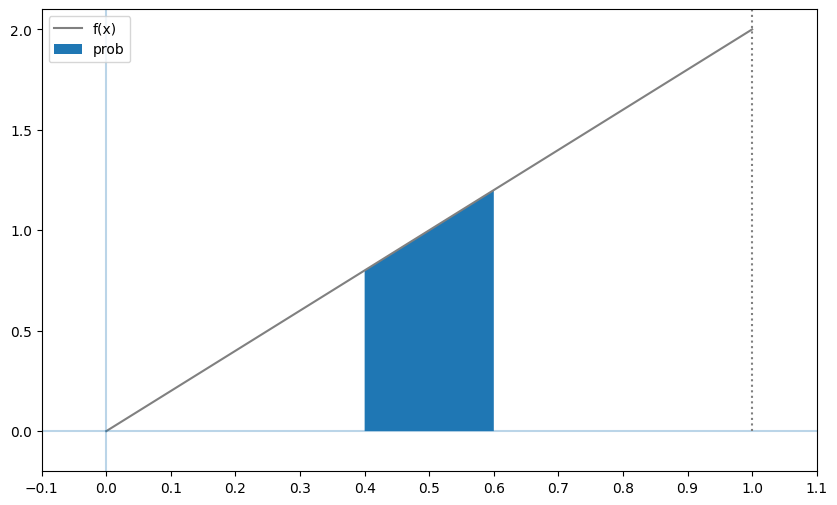

In [1001]:
xs = np.linspace(x_range[0], x_range[1], 100)
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)

ax.plot(xs, [f(x) for x in xs], label='f(x)', color='gray')
ax.hlines(0, -0.2, 1.2, alpha=0.3)
ax.vlines(0, -0.2, 2.2, alpha=0.3)
ax.vlines(xs.max(), 0, 2.2, linestyles=':', color='gray')

xs = np.linspace(0.4, 0.6, 100)
ax.fill_between(xs, [f(x) for x in xs], label='prob')
ax.set_xticks(np.arange(-0.2, 1.3, 0.1))
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.2, 2.1)
ax.legend()

plt.show()

In [1002]:
# 확률의 성질
from scipy.optimize import minimize_scalar

In [1003]:
res = minimize_scalar(f)

In [1004]:
res.fun # 함수의 최솟값은 fun 이라는 인스턴스 오브젝트 변수에 저장된다.

np.int64(0)

In [1005]:
integrate.quad(f, -np.inf, np.inf)[0]

1.000

### 누적분포함수
$F(x) = P(X <= x) = \int_{-\infty}^{x}f(x)\,dx$

In [1006]:
def F(x):
    return integrate.quad(f, -np.inf, x)[0]

In [1007]:
F(0.6) - F(0.4)

0.200

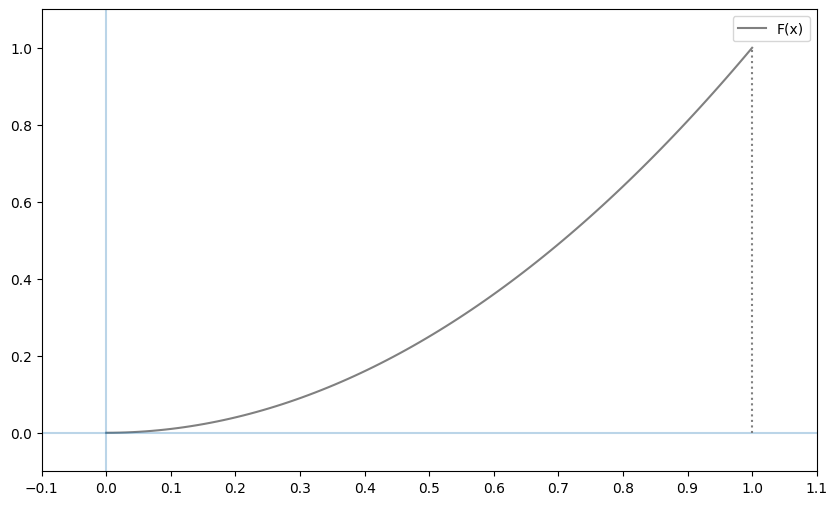

In [1008]:
xs = np.linspace(x_range[0], x_range[1], 100)
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.plot(xs, [F(x) for x in xs], label='F(x)', color='gray')
ax.hlines(0, -0.1, 1.1, alpha=0.3)
ax.vlines(0, -0.1, 1.1, alpha=0.3)
ax.vlines(xs.max(), 0, 1, linestyles=':', color='gray')
ax.set_xticks(np.arange(-0.1, 1.2, 0.1))
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.legend()
plt.show()

Y = 2X + 3

X -> [0, 1]

Y -> [3, 5]

In [1009]:
y_range = [3, 5]

def g(y):
    if y_range[0] <= y <= y_range[1]:
        return (y - 3) / 2
    else:
        return 0

In [1010]:
def G(y):
    return integrate.quad(g, -np.inf, y)[0]

기댓값

In [1011]:
def integrand(x):
    return x*f(x)

integrate.quad(integrand, -np.inf, np.inf)[0]

0.667

In [1012]:
def E(X, g=lambda x: x):
    x_range, f = X
    def integrand(x):
        return g(x) * f(x)
    return integrate.quad(integrand, -np.inf, np.inf)[0]

In [1013]:
E(X)

0.667